<a href="https://colab.research.google.com/github/mohdaffamyhonest-max/Prediksi-Durasi-Kualitas-Tidur-Notebook/blob/main/Done_Revisi_Skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Import utama ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Model & evaluasi ---
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("synthetic_coffee_health_10000.csv")

df.head()


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
# Cek info umum
df.info()

# Cek missing values
print(df.isnull().sum())

# Statistik deskriptif
print("\n Nilai Statistik Deskriptif")
df.describe()


# Cek kategori target (misalnya 'Kegagalan Kontrasepsi' atau 'Sleep Quality')
# Ubah hasil value_counts() menjadi DataFrame untuk tampilan yang lebih rapi dengan spasi
sleep_quality_counts = df['Sleep_Quality'].value_counts().reset_index()
sleep_quality_counts.columns = ['Kategori_Sleep_Quality', 'Jumlah']
print(sleep_quality_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [ ]:
# --- Bersihkan data ---
df = df.drop_duplicates().dropna()

# --- Tangani outlier (misal pada Heart Rate, BMI, Age) ---
for col in ['Heart_Rate', 'BMI', 'Age']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# --- Ubah 'Stress Level' ke numerik ---
df['Stress_Level'] = df['Stress_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})

# --- Encode kolom kategori lain ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes('object'):
    df[col] = le.fit_transform(df[col])




In [ ]:
df['Sleep_Quality'] = df['Sleep_Quality'].replace({
    "Poor": "Buruk",
    "Fair": "Cukup",
    "Good": "Baik",
    "Excellent": "Baik"
})

In [ ]:
# --- Cek hasil setelah encoding ---
print("\n=== 5 Data Teratas Setelah Pembersihan dan Encoding ===")
print(df.head())

print("\n=== Info Dataset ===")
print(df.info())

# Cek missing values
print(df.isnull().sum())




=== 5 Data Teratas Setelah Pembersihan dan Encoding ===
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
2   3   42       1        2            5.3        503.7          5.9   
3   4   53       1        7            2.6        249.2          7.3   
4   5   32       0       15            3.1        298.0          5.3   
6   7   53       1        6            2.7        252.1          7.8   
7   8   44       0        3            4.5        423.5          5.5   

   Sleep_Quality   BMI  Heart_Rate  Stress_Level  Physical_Activity_Hours  \
2              1  22.7          59             2                     11.2   
3              2  24.7          71             1                      6.6   
4              1  24.1          76             2                      8.5   
6              2  24.3          58             1                      1.0   
7              1  15.8          62             2                      0.7   

   Health_Issues  Occupation  Smoking  Alcohol_

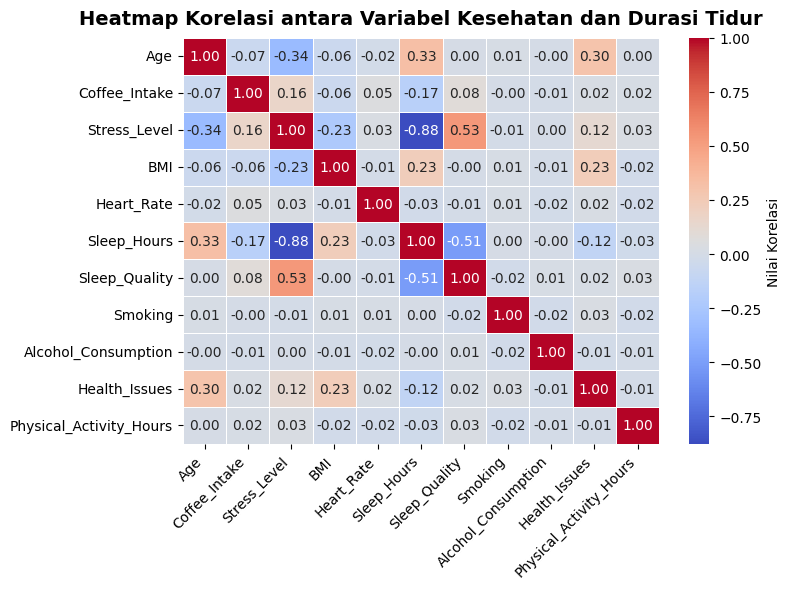

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Pilih hanya 6 variabel yang ingin dianalisis ===
selected_columns = [
    'Age',
    'Coffee_Intake',
    'Stress_Level',
    'BMI',
    'Heart_Rate',
    'Sleep_Hours',
    'Sleep_Quality',
    'Smoking',
    'Alcohol_Consumption',
    'Health_Issues',
    'Physical_Activity_Hours'
]

# --- Buat subset dataframe ---
df_selected = df[selected_columns]

# --- Visualisasi Heatmap Korelasi ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_selected.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Nilai Korelasi'}
)
plt.title("Heatmap Korelasi antara Variabel Kesehatan dan Durasi Tidur", fontsize=14, fontweight='bold', pad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['Physical_Activity_Hours', 'Stress_Level', 'Coffee_Intake',
        'Heart_Rate', 'BMI', 'Age','Smoking','Alcohol_Consumption']]
X2 = df[['Physical_Activity_Hours', 'Stress_Level', 'Coffee_Intake',
        'Heart_Rate','Smoking','Alcohol_Consumption','Health_Issues']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X2_scaled = scaler.fit_transform(X2)

In [ ]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

# Target
y_quality = df['Sleep_Quality']

# 1. Split data (stratify untuk menjaga proporsi kelas di train & test)
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X2_scaled, y_quality, test_size=0.2, random_state=42, stratify=y_quality
)

print("Sebelum SMOTE-Tomek:")
print(y_train_q.value_counts())

# 2. Terapkan SMOTE + Tomek Links ke TRAINING set saja
sm = SMOTETomek(random_state=42)
X_train_q, y_train_q = sm.fit_resample(X_train_q, y_train_q)

print("\nSesudah SMOTE-Tomek:")
print(y_train_q.value_counts())


Sebelum SMOTE-Tomek:
Sleep_Quality
1    1637
3     768
2     656
0     175
Name: count, dtype: int64

Sesudah SMOTE-Tomek:
Sleep_Quality
1    1635
3    1635
2    1590
0    1590
Name: count, dtype: int64


In [ ]:
print("\n==================== MODEL 1: SLEEP DURATION ====================")

X_dur = X
y_dur = df['Sleep_Hours']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dur, y_dur, test_size=0.2, random_state=42
)

# Scaling
scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)

# Model regresi (boleh default, sesuai keperluan)
model_duration = GradientBoostingRegressor(random_state=42)
model_duration.fit(X_train_d, y_train_d)

# Predict
y_pred_d = model_duration.predict(X_test_d)

# Evaluasi
print("R2 Score :", r2_score(y_test_d, y_pred_d))
print("MSE      :", mean_squared_error(y_test_d, y_pred_d))
print("RMSE     :", np.sqrt(mean_squared_error(y_test_d, y_pred_d)))

print("\nFeature Importance (Sleep Duration):")
for col, score in zip(X.columns, model_duration.feature_importances_):
    print(f"{col} : {score:.4f}")


==================== MODEL 1: SLEEP DURATION ====================
R2 Score : 0.7806657371804968
MSE      : 0.2834673906588944
RMSE     : 0.5324165574612555

Feature Importance (Sleep Duration):
Physical_Activity_Hours : 0.0078
Stress_Level : 0.9561
Coffee_Intake : 0.0099
Heart_Rate : 0.0067
BMI : 0.0103
Age : 0.0084
Smoking : 0.0006
Alcohol_Consumption : 0.0002


In [ ]:
print("\n==================== MODEL 2: SLEEP QUALITY ====================")

y_quality = df['Sleep_Quality']

# Train-test split
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X2_scaled, y_quality, test_size=0.2, random_state=42
)

# SMOTE untuk imbalance
sm = SMOTE(random_state=42)
X_train_q, y_train_q = sm.fit_resample(X_train_q, y_train_q)

# MODEL DARI KAMU (lebih bagus)
gb = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.5,
    max_depth=3,
    subsample=0.8,
    min_samples_split=5,
    random_state=42
)

# Train
gb.fit(X_train_q, y_train_q)

# Predict
y_pred_q = gb.predict(X_test_q)

# Evaluasi
print("\nClassification Report:")
print(classification_report(y_test_q, y_pred_q))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_q, y_pred_q))

print("\nFeature Importance (Sleep Quality):")
for col, score in zip(X2.columns, gb.feature_importances_):
    print(f"{col} : {score:.4f}")


==================== MODEL 2: SLEEP QUALITY ====================

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.23      0.26        44
           1       1.00      1.00      1.00       413
           2       0.78      0.84      0.81       147
           3       1.00      1.00      1.00       206

    accuracy                           0.93       810
   macro avg       0.77      0.77      0.77       810
weighted avg       0.92      0.93      0.92       810


Confusion Matrix:
[[ 10   0  34   0]
 [  0 413   0   0]
 [ 24   0 123   0]
 [  0   0   0 206]]

Feature Importance (Sleep Quality):
Physical_Activity_Hours : 0.0716
Stress_Level : 0.7609
Coffee_Intake : 0.0823
Heart_Rate : 0.0695
Smoking : 0.0035
Alcohol_Consumption : 0.0060
Health_Issues : 0.0061


In [ ]:
from sklearn.ensemble import RandomForestClassifier # Random Forest Coba Perbandinngan

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_q, y_train_q)
y_pred_rf = rf.predict(X_test_q)

print(classification_report(y_test_q, y_pred_rf))


              precision    recall  f1-score   support

           0       0.19      0.18      0.19        44
           1       1.00      1.00      1.00       413
           2       0.76      0.77      0.76       147
           3       1.00      1.00      1.00       206

    accuracy                           0.91       810
   macro avg       0.74      0.74      0.74       810
weighted avg       0.91      0.91      0.91       810



In [ ]:
print("Train Accuracy :", gb.score(X_train_q, y_train_q))
print("Test Accuracy  :", gb.score(X_test_q, y_test_q))


Train Accuracy : 0.988984088127295
Test Accuracy  : 0.928395061728395


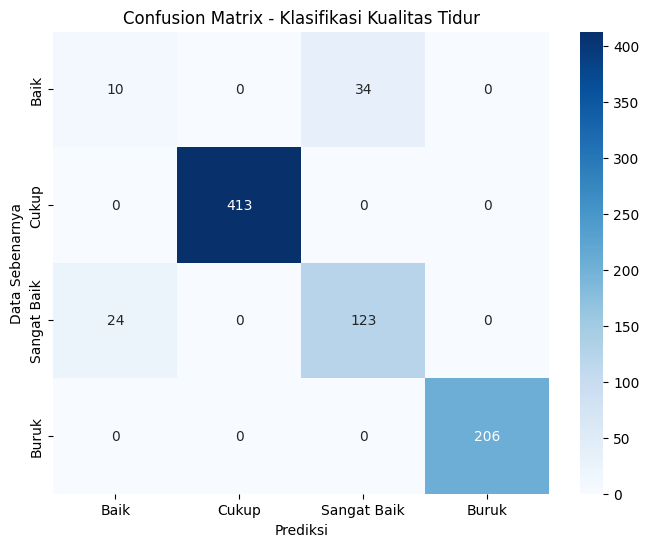

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Hitung Confusion Matrix ---
cm = confusion_matrix(y_test_q, y_pred_q)

# --- Label kelas sesuai tabel ---
class_labels = ["Baik", "Cukup", "Sangat Baik", "Buruk"]

# --- Plot Confusion Matrix ---
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix - Klasifikasi Kualitas Tidur")
plt.xlabel("Prediksi")
plt.ylabel("Data Sebenarnya")
plt.show()


/tmp/ipython-input-889346427.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')


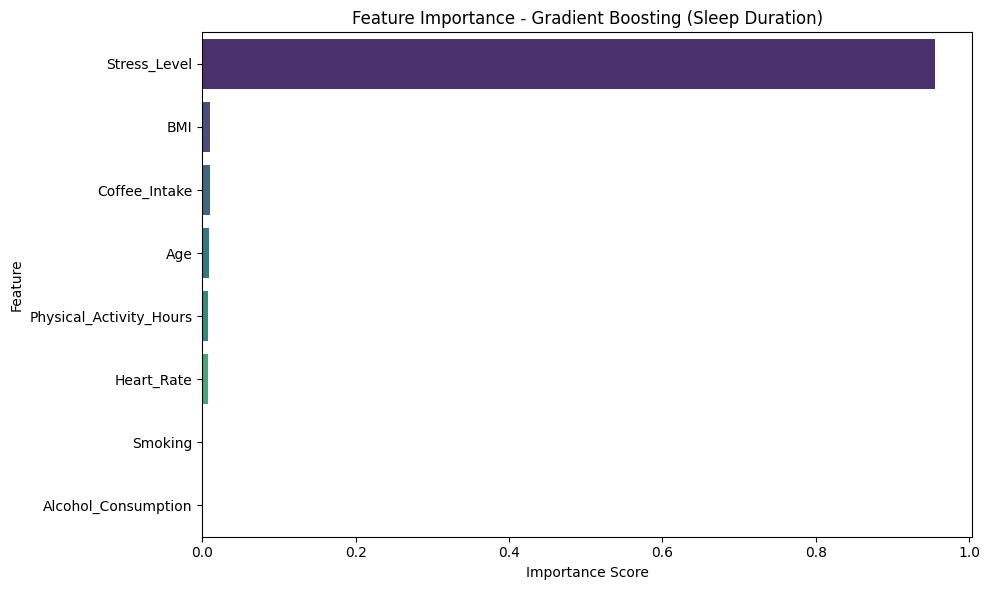

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Ambil nilai feature importance dari model ---
importances = model_duration.feature_importances_
feature_names = X.columns

# --- Urutkan berdasarkan nilai importance ---
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

# --- Plot Feature Importance ---
plt.figure(figsize=(10,6))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')

plt.title("Feature Importance - Gradient Boosting (Sleep Duration)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2913302120.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')


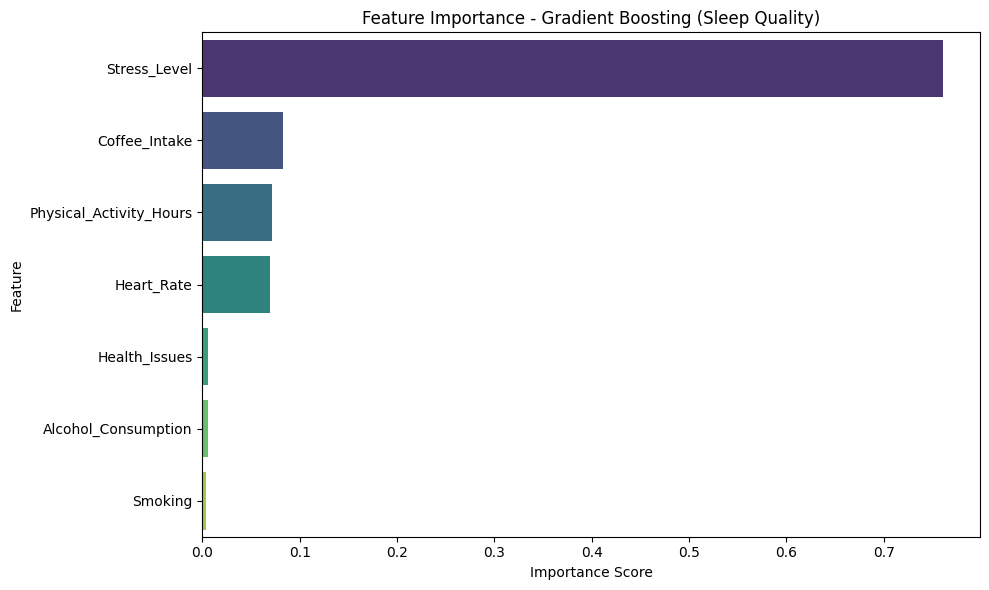

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Ambil nilai feature importance dari model ---
importances = gb.feature_importances_
feature_names = X2.columns

# --- Urutkan berdasarkan nilai importance ---
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

# --- Plot Feature Importance ---
plt.figure(figsize=(10,6))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')

plt.title("Feature Importance - Gradient Boosting (Sleep Quality)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# === Scaling terpisah ===
scaler_reg = StandardScaler()   # untuk regresi
scaler_clf = StandardScaler()   # untuk klasifikasi

X_scaled = scaler_reg.fit_transform(X)     # 8 fitur
X2_scaled = scaler_clf.fit_transform(X2)   # 7 fitur


In [ ]:
print("\n=== Input Data Baru untuk Prediksi Durasi Tidur (Regresi) ===")

age = float(input("Umur: "))
coffee = float(input("Konsumsi kopi per hari: "))
stress = float(input("Tingkat stres (1–3): "))
bmi = float(input("BMI: "))
heart_rate = float(input("Detak jantung per menit: "))
activity = float(input("Durasi aktivitas fisik per hari (jam): "))
smoking = float(input("Apakah merokok? (0=tidak, 1=ya): "))
alcohol = float(input("Konsumsi alkohol per minggu: "))

# === DataFrame input baru (harus sama urutan kolomnya dengan X) ===
new_data_reg = pd.DataFrame([{
    'Physical_Activity_Hours': activity,
    'Stress_Level': stress,
    'Coffee_Intake': coffee,
    'Heart_Rate': heart_rate,
    'BMI': bmi,
    'Age': age,
    'Smoking': smoking,
    'Alcohol_Consumption': alcohol
}])[X.columns]   # pastikan urut sama seperti X

# === Scaling sesuai model regresi terbaru ===
new_data_reg_scaled = scaler_d.transform(new_data_reg)

# === Prediksi durasi tidur ===
pred_sleep = model_duration.predict(new_data_reg_scaled)[0]

print(f"\n⏰ Prediksi Durasi Tidur Anda: {pred_sleep:.2f} jam/hari")



=== Input Data Baru untuk Prediksi Durasi Tidur (Regresi) ===
Umur: 22
Konsumsi kopi per hari: 2
Tingkat stres (1–3): 2
BMI: 23
Detak jantung per menit: 70
Durasi aktivitas fisik per hari (jam): 2
Apakah merokok? (0=tidak, 1=ya): 0
Konsumsi alkohol per minggu: 0

⏰ Prediksi Durasi Tidur Anda: 5.56 jam/hari


In [ ]:
print("\n=== Input Data Baru untuk Prediksi Kualitas Tidur (Multiclass) ===")

activity2 = float(input("Durasi aktivitas fisik (jam): "))
stress2 = float(input("Tingkat stres (1–3): "))
coffee2 = float(input("Konsumsi kopi per hari: "))
heart2 = float(input("Detak jantung per menit: "))
smoke = int(input("Apakah merokok? (0=tidak, 1=ya): "))
alcohol = float(input("Konsumsi alkohol per minggu: "))
health = int(input("Apakah ada masalah kesehatan? (0=tidak, 1=ya): "))

# === Buat DataFrame input baru ===
new_data_clf = pd.DataFrame([{
    'Physical_Activity_Hours': activity2,
    'Stress_Level': stress2,
    'Coffee_Intake': coffee2,
    'Heart_Rate': heart2,
    'Smoking': smoke,
    'Alcohol_Consumption': alcohol,
    'Health_Issues': health
}])[X2.columns]  # pastikan urut sesuai X2

# === Scaling ===
new_data_clf_scaled = scaler_clf.transform(new_data_clf)

# === Prediksi ===
pred_class = gb.predict(new_data_clf_scaled)[0]
pred_proba = gb.predict_proba(new_data_clf_scaled)[0]

# === Map label ===
label_map = {
    0: "Baik",
    1: "Cukup",
    2: "Baik",
    3: "Buruk"
}

pred_label = label_map[pred_class]
confidence = max(pred_proba) * 100

print(f"\n💤 Prediksi Kualitas Tidur Anda: {pred_label}")



=== Input Data Baru untuk Prediksi Kualitas Tidur (Multiclass) ===
Durasi aktivitas fisik (jam): 2
Tingkat stres (1–3): 1
Konsumsi kopi per hari: 0
Detak jantung per menit: 67
Apakah merokok? (0=tidak, 1=ya): 0
Konsumsi alkohol per minggu: 0
Apakah ada masalah kesehatan? (0=tidak, 1=ya): 0

💤 Prediksi Kualitas Tidur Anda: Baik


In [ ]:
import pickle

# Simpan scaler regresi
with open('scaler_reg.pkl', 'wb') as f:
    pickle.dump(scaler_reg, f)

# Simpan scaler klasifikasi
with open('scaler_clf.pkl', 'wb') as f:
    pickle.dump(scaler_clf, f)

# Simpan model regresi
with open('model_durasi_tidur.pkl', 'wb') as f:
    pickle.dump(model_duration, f)

# Simpan model klasifikasi
with open('model_kualitas_tidur.pkl', 'wb') as f:
    pickle.dump(gb, f)

from sklearn.preprocessing import LabelEncoder
import pickle

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Sleep_Quality'])

# Simpan encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n✅ Semua model dan scaler berhasil disimpan!")



✅ Semua model dan scaler berhasil disimpan!


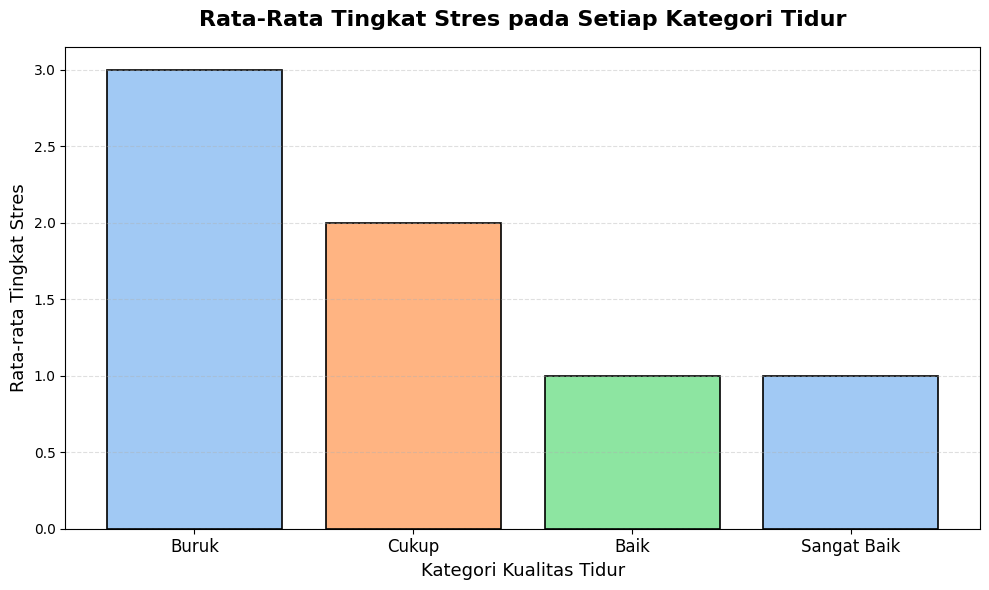

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the label map based on previous steps (from dYBi3C3tAU2F)
label_map = {
    0: "Baik",
    1: "Cukup",
    2: "Sangat Baik", # Assuming 0 and 2 both represent 'Baik' after encoding
    3: "Buruk"
}

# Create a temporary column for plotting with descriptive labels
df['Sleep_Quality_Category'] = df['Sleep_Quality'].map(label_map)

# Hitung rata-rata stres per kategori tidur
# Reindex with the desired order of categories
mean_stress = df.groupby("Sleep_Quality_Category")["Stress_Level"].mean().reindex(["Buruk", "Cukup", "Baik","Sangat Baik"])

plt.figure(figsize=(10, 6))

# Warna estetik pastel
colors = sns.color_palette("pastel")[:3] # Adjust to 3 colors for 3 unique categories

bars = plt.bar(
    mean_stress.index,
    mean_stress.values,
    color=colors,
    edgecolor='black',
    linewidth=1.2
)



# === Judul & Label ===
plt.title("Rata-Rata Tingkat Stres pada Setiap Kategori Tidur",
          fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Kategori Kualitas Tidur", fontsize=13)
plt.ylabel("Rata-rata Tingkat Stres", fontsize=13)

# === Label horizontal ===
plt.xticks(rotation=0, fontsize=12)

# === Grid tipis ===
plt.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

# Drop the temporary column if it's no longer needed
df = df.drop(columns=['Sleep_Quality_Category'])

/tmp/ipython-input-3627334268.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


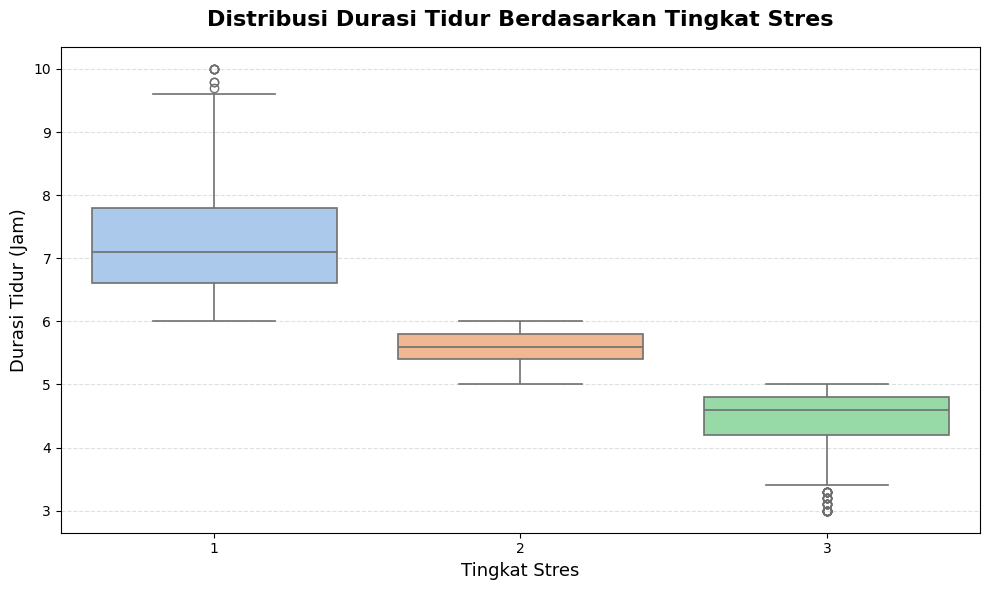

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Stress_Level",     # variabel independen
    y="Sleep_Hours",      # variabel dependen
    data=df,
    palette="pastel",
    linewidth=1.2
)

# Judul & label
plt.title(
    "Distribusi Durasi Tidur Berdasarkan Tingkat Stres",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tingkat Stres", fontsize=13)
plt.ylabel("Durasi Tidur (Jam)", fontsize=13)

# Grid horizontal
plt.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()
